In [18]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../Dataset/HR_Enhanced.csv")

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,AgeGroup,EmployeeExperienceIndex,RiskScore,RiskCategory
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,0,1,6,4,0,5,36-45,2.00,2,Low Risk
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,3,3,10,7,1,7,46-55,3.00,3,Medium Risk
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,3,3,0,0,0,0,36-45,3.00,5,High Risk
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,3,8,7,3,0,26-35,3.25,5,High Risk
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,3,3,2,2,2,2,26-35,2.50,5,High Risk


In [19]:
risk_dist = df['RiskCategory'].value_counts()

risk_dist

RiskCategory
Low Risk         727
Medium Risk      496
High Risk        208
Critical Risk     39
Name: count, dtype: int64

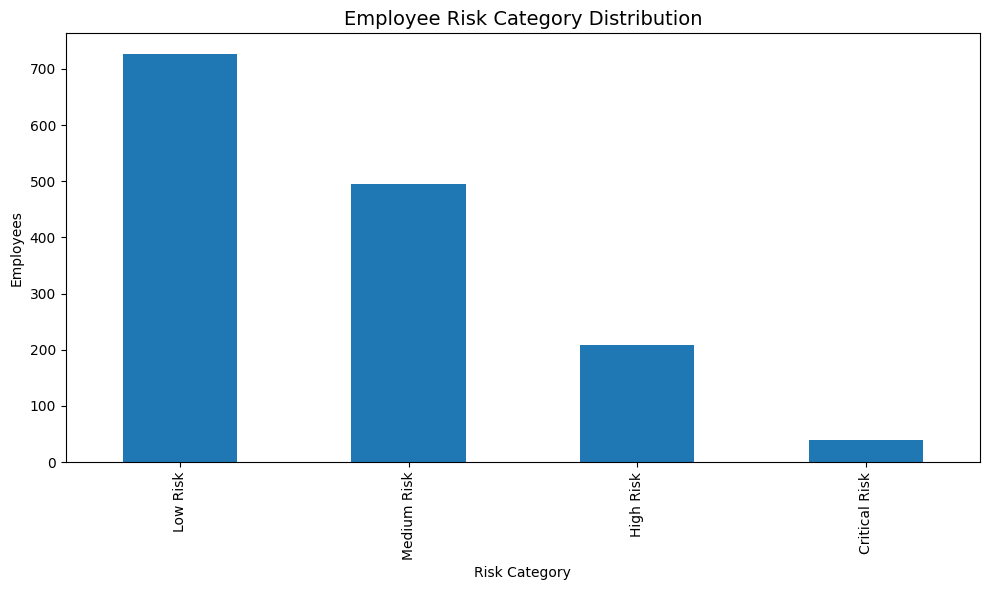

In [20]:
plt.figure(figsize=(10,6))

risk_dist.plot(
    kind='bar'
)

plt.title(
    'Employee Risk Category Distribution',
    fontsize=14
)

plt.xlabel('Risk Category')
plt.ylabel('Employees')

plt.tight_layout()

plt.show()

In [21]:
risk_attrition = pd.crosstab(
    df['RiskCategory'],
    df['Attrition']
)

risk_attrition

Attrition,No,Yes
RiskCategory,,
Critical Risk,15,24
High Risk,130,78
Low Risk,679,48
Medium Risk,409,87


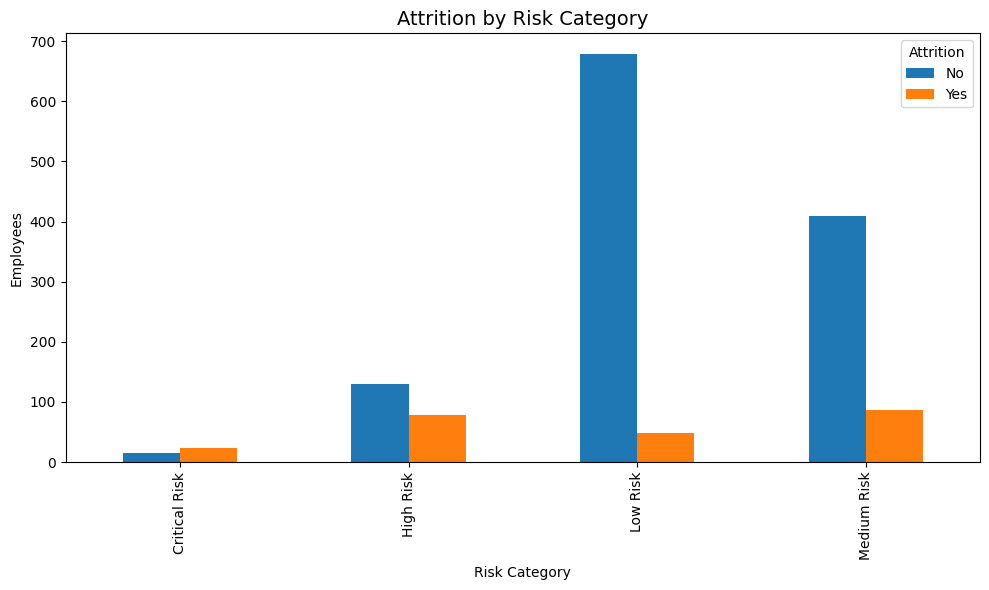

In [22]:
risk_attrition.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title(
    'Attrition by Risk Category',
    fontsize=14
)

plt.xlabel('Risk Category')
plt.ylabel('Employees')

plt.tight_layout()

plt.show()

In [23]:
high_risk = df[
    df['RiskCategory'].isin(
        ['High Risk','Critical Risk']
    )
]

high_risk.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,AgeGroup,EmployeeExperienceIndex,RiskScore,RiskCategory
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,3,3,0,0,0,0,36-45,3.00,5,High Risk
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,3,8,7,3,0,26-35,3.25,5,High Risk
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,3,3,2,2,2,2,26-35,2.50,5,High Risk
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,3,2,1,0,0,0,55+,1.75,7,Critical Risk
16,32,No,Travel_Rarely,334,Research & Development,5,2,Life Sciences,1,21,...,5,2,6,2,0,5,26-35,2.25,6,High Risk


In [24]:
print(
    "High Risk Employees:",
    len(high_risk)
)

High Risk Employees: 247


In [25]:
dept_risk = pd.crosstab(
    df['Department'],
    df['RiskCategory']
)

dept_risk

RiskCategory,Critical Risk,High Risk,Low Risk,Medium Risk
Department,,,,
Human Resources,2,11,29,21
Research & Development,31,139,450,341
Sales,6,58,248,134


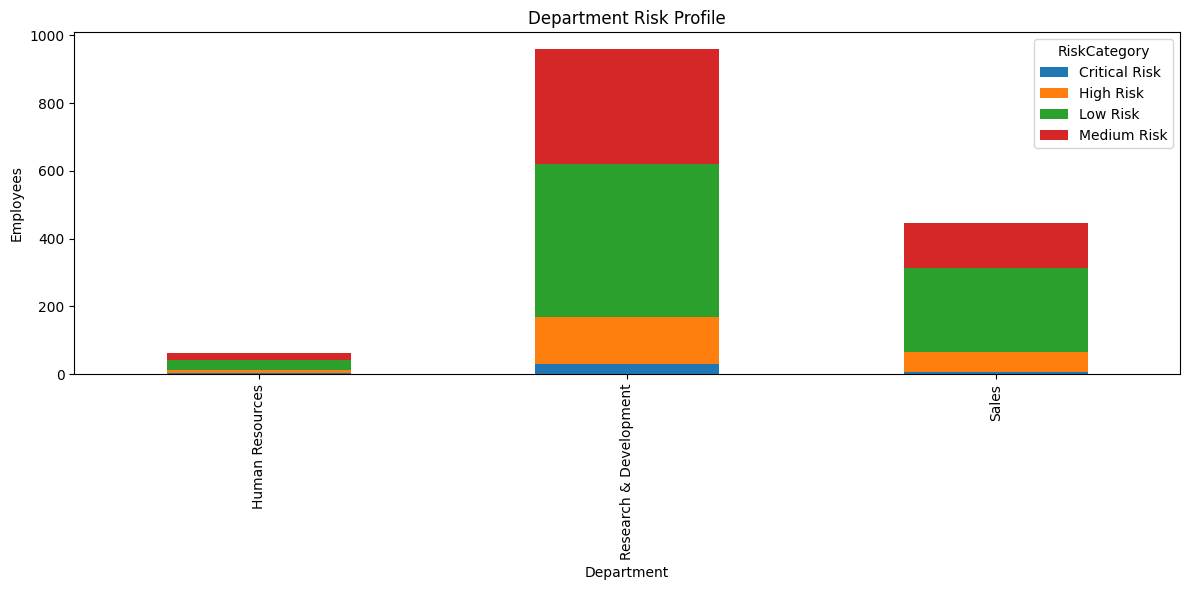

In [26]:
dept_risk.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6)
)

plt.title(
    'Department Risk Profile'
)

plt.xlabel('Department')
plt.ylabel('Employees')

plt.tight_layout()

plt.show()

In [27]:
job_risk = pd.crosstab(
    df['JobRole'],
    df['RiskCategory']
)

job_risk

RiskCategory,Critical Risk,High Risk,Low Risk,Medium Risk
JobRole,,,,
Healthcare Representative,1,7,92,31
Human Resources,2,11,21,18
Laboratory Technician,11,57,71,120
Manager,0,1,79,22
Manufacturing Director,1,8,97,39
Research Director,0,4,64,12
Research Scientist,18,63,84,127
Sales Executive,0,28,207,91
Sales Representative,6,29,12,36


In [28]:
job_risk['TotalRisk'] = (
    job_risk['High Risk']
    +
    job_risk['Critical Risk']
)

top_roles = job_risk.sort_values(
    'TotalRisk',
    ascending=False
)

top_roles.head(10)

RiskCategory,Critical Risk,High Risk,Low Risk,Medium Risk,TotalRisk
JobRole,,,,,
Research Scientist,18,63,84,127,81
Laboratory Technician,11,57,71,120,68
Sales Representative,6,29,12,36,35
Sales Executive,0,28,207,91,28
Human Resources,2,11,21,18,13
Manufacturing Director,1,8,97,39,9
Healthcare Representative,1,7,92,31,8
Research Director,0,4,64,12,4
Manager,0,1,79,22,1


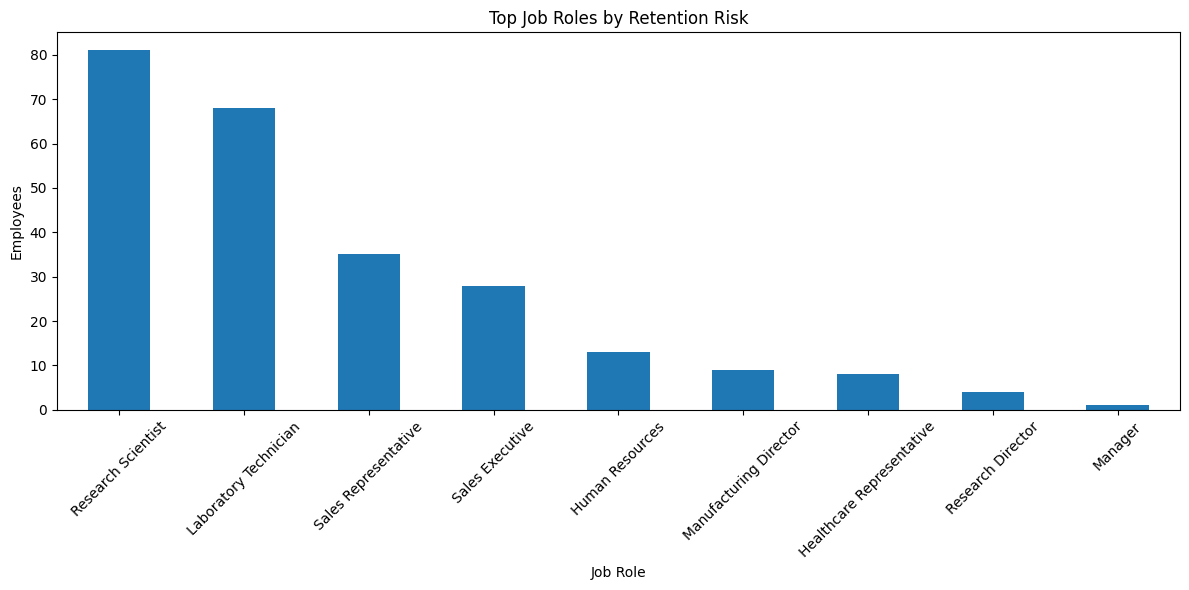

In [29]:
top_roles['TotalRisk'].head(10).plot(
    kind='bar',
    figsize=(12,6)
)

plt.title(
    'Top Job Roles by Retention Risk'
)

plt.xlabel('Job Role')
plt.ylabel('Employees')

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [30]:
df['SalaryBand'] = pd.qcut(
    df['MonthlyIncome'],
    q=4,
    labels=[
        'Low',
        'Medium',
        'High',
        'Very High'
    ]
)

In [31]:
salary_risk = pd.crosstab(
    df['SalaryBand'],
    df['RiskCategory']
)

salary_risk

RiskCategory,Critical Risk,High Risk,Low Risk,Medium Risk
SalaryBand,,,,
Low,27,104,66,172
Medium,12,82,108,164
High,0,8,270,89
Very High,0,14,283,71


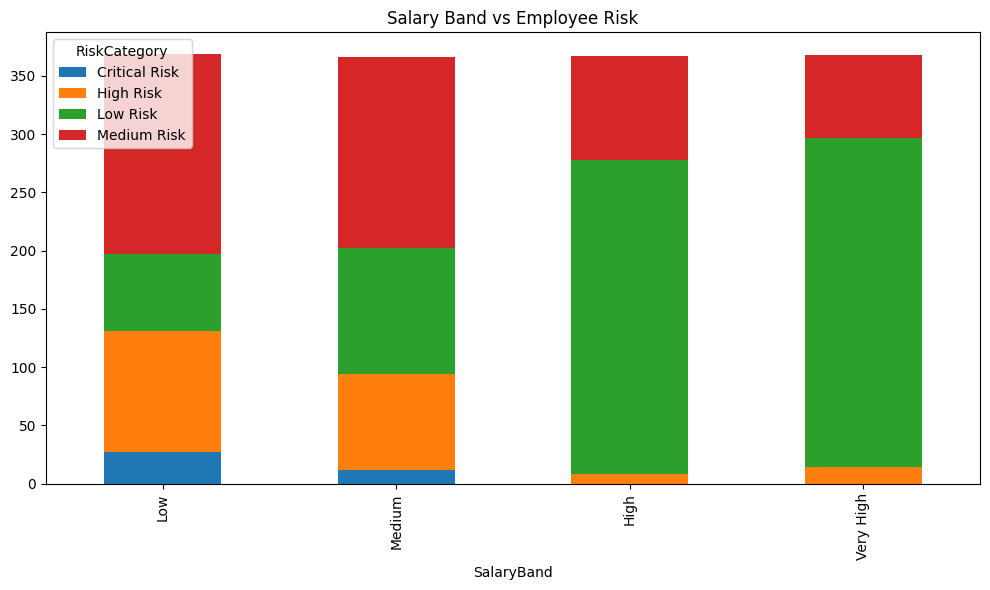

In [32]:
salary_risk.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6)
)

plt.title(
    'Salary Band vs Employee Risk'
)

plt.tight_layout()

plt.show()

In [33]:
summary = pd.DataFrame({

    'Total Employees':
    [len(df)],

    'High Risk Employees':
    [len(high_risk)],

    'Attrition Rate (%)':
    [
        round(
            (
                df['Attrition']
                .eq('Yes')
                .mean()
            )*100,
            2
        )
    ]
})

summary

,Total Employees,High Risk Employees,Attrition Rate (%)
0,1470,247,16.12


In [34]:
df.to_csv(
    "../Dataset/HR_Strategic.csv",
    index=False
)

print(
    "Strategic Dataset Saved"
)

Strategic Dataset Saved
